# Impact comparison
<!-- markdownlint-disable MD013 -->

Check that:

- rainfall is good predictor of flood extent
- flood extent is good predictor of impact
- CERF/CBPF allocations are well-matched with impact

In [388]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [389]:
import calendar

import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from src.constants import *
from src.datasources import era5, seas5
from src.utils.timeseries import detrend_column

In [390]:
pcode = "SS"

In [391]:
query = f"SELECT * FROM public.polygon WHERE pcode = '{pcode}'"
df_adm = pd.read_sql(query, stratus.get_engine(stage="prod"))
adm_name = df_adm.iloc[0]["name"]

In [392]:
adm_name

'South Sudan'

## Load data

### Exposure

In [393]:
query = f"SELECT * FROM app.floodscan_exposure WHERE pcode = '{pcode}'"

In [394]:
df_exp_daily = pd.read_sql(
    query, stratus.get_engine(stage="prod"), parse_dates=["valid_date"]
)

In [395]:
df_exp_yearly = (
    df_exp_daily.groupby(df_exp_daily["valid_date"].dt.year)["sum"]
    .agg(["mean", "max", "min"])
    .reset_index()
)
df_exp_yearly["max_diff"] = df_exp_yearly["max"] - df_exp_yearly["min"]
df_exp_yearly["mean_diff"] = df_exp_yearly["mean"] - df_exp_yearly["min"]

In [396]:
df_exp_yearly["max_prev"] = df_exp_yearly["max"].shift()
df_exp_yearly["mean_prev"] = df_exp_yearly["mean"].shift()

In [397]:
window = 3
df_exp_yearly[f"mean_roll{window}"] = (
    df_exp_yearly["mean"].rolling(window).mean()
)
df_exp_yearly[f"max_diff_mean_roll{window}"] = (
    df_exp_yearly["max"] / df_exp_yearly[f"mean_roll{window}"]
)

<Axes: xlabel='valid_date'>

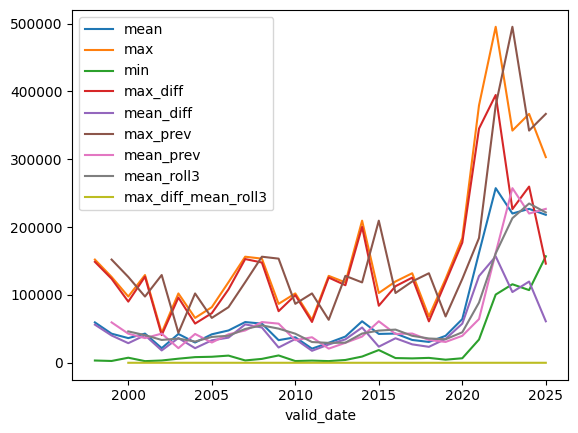

In [398]:
df_exp_yearly.set_index("valid_date").plot()

In [405]:
df_exp_yearly = df_exp_yearly.rename(
    columns={
        x: f"{x}_exp"
        for x in df_exp_yearly.columns
        if x != "valid_date" and "exp" not in x
    }
)

In [406]:
df_exp_yearly

,valid_date,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,max_prev_exp,mean_prev_exp,mean_roll3_exp,max_diff_mean_roll3_exp
0,1998,59556.785311,152155.0,3343.0,148812.0,56213.785311,NaN,NaN,NaN,NaN
1,1999,42893.224658,126544.0,2663.0,123881.0,40230.224658,152155.0,59556.785311,NaN,NaN
2,2000,36362.508197,97660.0,7472.0,90188.0,28890.508197,126544.0,42893.224658,46270.839388,2.110617
3,2001,43013.652055,129377.0,2423.0,126954.0,40590.652055,97660.0,36362.508197,40756.461636,3.174392
4,2002,21579.810959,44173.0,3374.0,40799.0,18205.810959,129377.0,43013.652055,33651.990403,1.312642
5,2003,42480.830137,102194.0,6037.0,96157.0,36443.830137,44173.0,21579.810959,35691.431050,2.863264
6,2004,29861.836066,66140.0,8338.0,57802.0,21523.836066,102194.0,42480.830137,31307.492387,2.112593
7,2005,41970.375342,81974.0,8870.0,73104.0,33100.375342,66140.0,29861.836066,38104.347182,2.151303
8,2006,47637.558904,118770.0,10580.0,108190.0,37057.558904,81974.0,41970.375342,39823.256771,2.982428
9,2007,60032.915068,156370.0,3439.0,152931.0,56593.915068,118770.0,47637.558904,49880.283105,3.134906


### SEAS5

Load and filter SEAS5 data to specific `issued_month`.

In [407]:
df_seas5_all = seas5.load_seas5(pcode=pcode)

In [408]:
issued_month = 5
issued_mo_str = calendar.month_abbr[issued_month]
df_seas5_imo = df_seas5_all[
    df_seas5_all["issued_date"].dt.month == issued_month
]

In [409]:
valid_months_override = [7, 8, 9]
df_seas5_imo = df_seas5_imo[
    df_seas5_imo["valid_date"].dt.month.isin(valid_months_override)
]

In [410]:
valid_months = sorted(df_seas5_imo["valid_date"].dt.month.unique())
valid_mo_str = "".join([calendar.month_abbr[x][0] for x in valid_months])
valid_mo_str

'JAS'

In [411]:
df_seas5_yearly = (
    df_seas5_imo.groupby(df_seas5_imo["valid_date"].dt.year)["mean"]
    .mean()
    .reset_index()
)

In [412]:
df_seas5_yearly = detrend_column(df_seas5_yearly, col="mean", max_index=2024)
# df_seas5_yearly = detrend_column(
#     df_seas5_yearly, col="mean", min_index=2000, max_index=2024
# )

Text(0.5, 1.0, 'seas5')

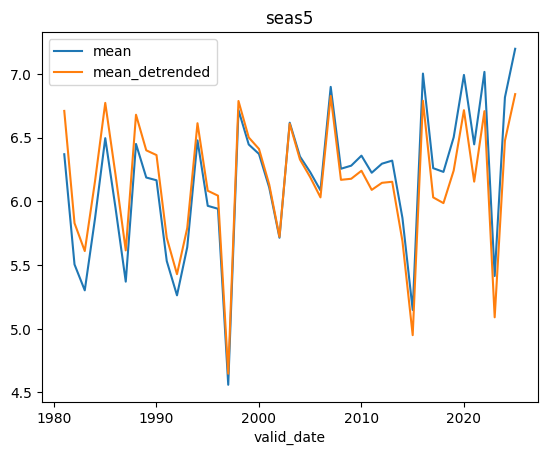

In [440]:
ax = df_seas5_yearly.set_index("valid_date").plot()
ax.set_title("seas5")

In [414]:
df_seas5_yearly

,valid_date,mean,mean_detrended
0,1981,6.368746,6.708666
1,1982,5.503742,5.827851
2,1983,5.300693,5.608992
3,1984,5.864295,6.156784
4,1985,6.494820,6.771499
5,1986,5.948166,6.209034
6,1987,5.368880,5.613938
7,1988,6.449613,6.678861
8,1989,6.186039,6.399476
9,1990,6.164523,6.362151


In [415]:
df_seas5_monthwise = df_seas5_imo.copy()
df_seas5_monthwise["valid_month"] = df_seas5_monthwise["valid_date"].dt.month
df_seas5_monthwise["valid_year"] = df_seas5_monthwise["valid_date"].dt.year
df_seas5_monthwise = df_seas5_monthwise.pivot(
    index="valid_year", columns="valid_month", values="mean"
)
df_seas5_monthwise = df_seas5_monthwise.rename(
    columns={x: f"mean_seas5_mo{x}" for x in df_seas5_monthwise.columns}
).reset_index()
df_seas5_monthwise

valid_month,valid_year,mean_seas5_mo7,mean_seas5_mo8,mean_seas5_mo9
0,1981,6.484909,6.818319,5.803011
1,1982,5.562617,6.300509,4.648099
2,1983,4.728759,6.144759,5.028562
3,1984,5.406262,6.270651,5.915972
4,1985,6.318805,6.781516,6.384139
5,1986,6.219306,6.426896,5.198295
6,1987,5.082358,6.146330,4.877951
7,1988,5.980745,7.213080,6.155013
8,1989,6.344725,6.554010,5.659381
9,1990,5.982011,7.016271,5.495287


### ERA5

Load and filter ERA5 data to same `valid_months` as SEAS5.

In [416]:
df_era5 = era5.load_era5(pcode=pcode)

In [417]:
df_era5_yearly = (
    df_era5[df_era5["valid_date"].dt.month.isin(valid_months)]
    .groupby(df_era5["valid_date"].dt.year)["mean"]
    .mean()
    .reset_index()
)
df_era5_yearly = df_era5_yearly[df_era5_yearly["valid_date"] < 2025]

In [418]:
df_era5_yearly = detrend_column(df_era5_yearly, "mean")
# df_era5_yearly = detrend_column(df_era5_yearly, "mean", min_index=2000)

Text(0.5, 1.0, 'era5')

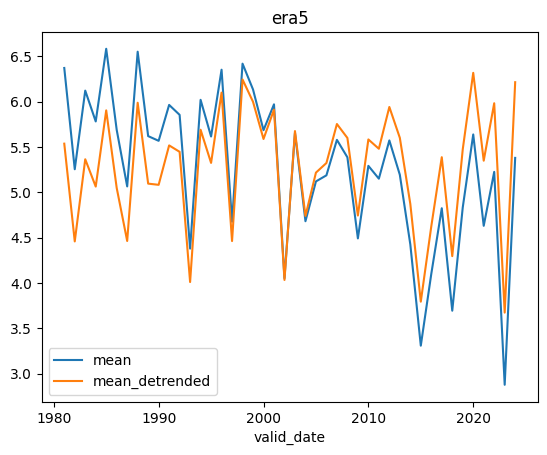

In [439]:
ax = df_era5_yearly.set_index("valid_date").plot()
ax.set_title("era5")

In [420]:
df_era5_yearly

,valid_date,mean,mean_detrended
0,1981,6.370742,5.535743
1,1982,5.253522,4.457360
2,1983,6.121003,5.363678
3,1984,5.780768,5.062280
4,1985,6.582485,5.902835
5,1986,5.688345,5.047531
6,1987,5.064137,4.462160
7,1988,6.550306,5.987167
8,1989,5.619099,5.094798
9,1990,5.567138,5.081673


#### Month-wise

In [421]:
df_era5

,iso3,pcode,valid_date,adm_level,mean,median,min,max,count,sum,std
0,SSD,SS,1981-01-01,0,0.054603,0.009537,0.000000,1.792908,21046,1149.16610,0.145196
1,SSD,SS,1981-02-01,0,0.212210,0.089645,0.000000,1.966476,21046,4466.17140,0.286513
2,SSD,SS,1981-03-01,0,2.475634,2.099991,0.045776,13.021469,21046,52102.19500,1.778386
3,SSD,SS,1981-04-01,0,1.769028,1.277924,0.219345,12.819290,21046,37230.95700,1.326667
4,SSD,SS,1981-05-01,0,4.789002,4.524231,1.287460,16.954422,21046,100789.33000,1.447784
...,...,...,...,...,...,...,...,...,...,...,...
526,SSD,SS,2019-12-01,0,0.343074,0.028610,0.000000,7.310867,21046,7220.32700,0.630404
527,SSD,SS,2022-12-01,0,0.090749,0.001907,0.000000,1.749039,21046,1909.89880,0.192860
528,SSD,SS,2024-10-01,0,2.905493,2.244949,0.255585,12.170792,21046,61149.01000,1.871944
529,SSD,SS,2025-01-01,0,0.004590,0.000000,0.000000,0.205994,21046,96.60530,0.016932


In [422]:
[x for x in df_era5_monthwise]

['valid_year',
 'mean_era5_mo1',
 'mean_era5_mo2',
 'mean_era5_mo3',
 'mean_era5_mo4',
 'mean_era5_mo5',
 'mean_era5_mo6',
 'mean_era5_mo7',
 'mean_era5_mo8',
 'mean_era5_mo9',
 'mean_era5_mo10',
 'mean_era5_mo11',
 'mean_era5_mo12',
 'mean_era5_mo1_detrended',
 'mean_era5_mo2_detrended',
 'mean_era5_mo3_detrended',
 'mean_era5_mo4_detrended',
 'mean_era5_mo5_detrended',
 'mean_era5_mo6_detrended',
 'mean_era5_mo7_detrended',
 'mean_era5_mo8_detrended',
 'mean_era5_mo9_detrended',
 'mean_era5_mo10_detrended',
 'mean_era5_mo11_detrended',
 'mean_era5_mo12_detrended']

In [423]:
df_era5_monthwise = df_era5[df_era5["valid_date"].dt.year < 2025].copy()
df_era5_monthwise["valid_month"] = df_era5_monthwise["valid_date"].dt.month
df_era5_monthwise["valid_year"] = df_era5_monthwise["valid_date"].dt.year
df_era5_monthwise = df_era5_monthwise.pivot(
    index="valid_year", columns="valid_month", values="mean"
)
df_era5_monthwise = df_era5_monthwise.rename(
    columns={x: f"mean_era5_mo{x}" for x in df_era5_monthwise.columns}
).reset_index()
for col in df_era5_monthwise:
    if col == "valid_year":
        continue
    df_era5_monthwise = detrend_column(
        df_era5_monthwise, col, index_col="valid_year"
    )

<Axes: >

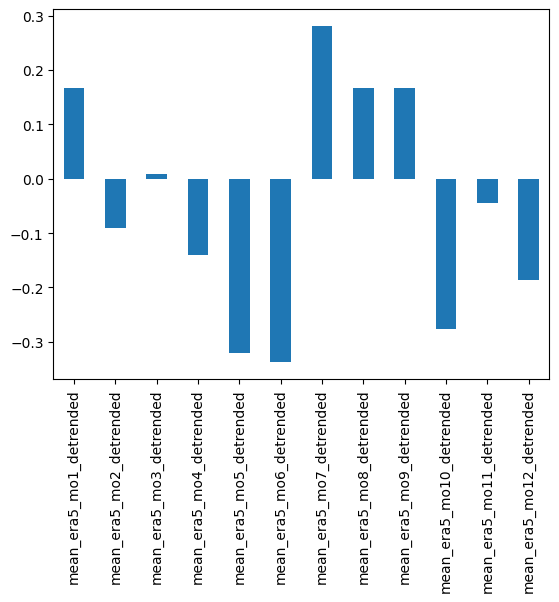

In [424]:
df_era5_monthwise.merge(
    df_exp_yearly.rename(columns={"valid_date": "valid_year"})
).corr()["mean_diff_exp"][
    [x for x in df_era5_monthwise if "detrended" in x]
].plot(
    kind="bar"
)

<Axes: >

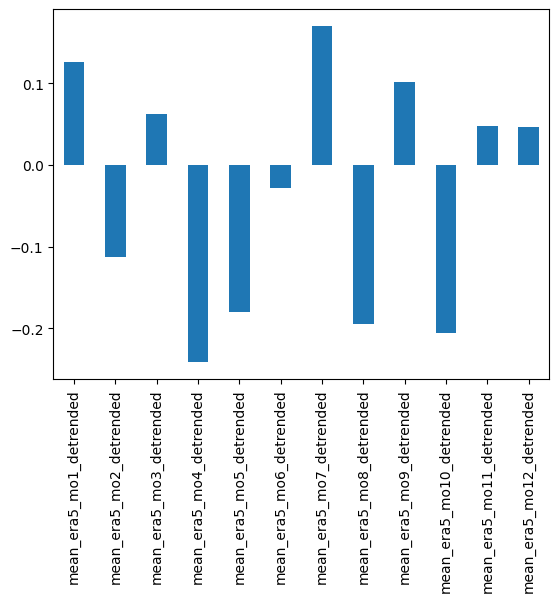

In [425]:
df_era5_monthwise.set_index("valid_year").shift().reset_index().merge(
    df_exp_yearly.rename(columns={"valid_date": "valid_year"})
).corr()["mean_diff_exp"][
    [x for x in df_era5_monthwise if "detrended" in x]
].plot(
    kind="bar"
)

### EM-DAT

In [426]:
blob_name = f"{PROJECT_PREFIX}/raw/emdat/emdat_ssd_flooding_2025-04-17.csv"
df_emdat_events = stratus.load_csv_from_blob(blob_name)

In [427]:
df_emdat_yearly = (
    df_emdat_events.groupby("Start Year")["Total Affected"].sum().reset_index()
)

In [428]:
# Ensure Start Year is the index
df_emdat_yearly = df_emdat_yearly.set_index("Start Year")

# Reindex to fill in all years 2000–2024
df_emdat_yearly = df_emdat_yearly.reindex(range(2000, 2025), fill_value=0)

# Reset index if you want to plot with "Start Year" as a column
df_emdat_yearly = df_emdat_yearly.reset_index().rename(
    columns={"index": "Start Year"}
)
df_emdat_yearly["Total Affected"] = df_emdat_yearly["Total Affected"].astype(
    int
)

In [429]:
df_emdat_yearly

,Start Year,Total Affected
0,2000,0
1,2001,0
2,2002,0
3,2003,0
4,2004,0
5,2005,0
6,2006,0
7,2007,0
8,2008,92791
9,2009,0


<Axes: xlabel='Start Year'>

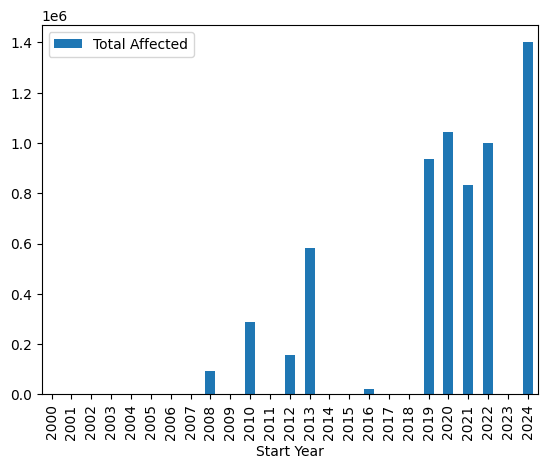

In [430]:
df_emdat_yearly.plot(x="Start Year", y="Total Affected", kind="bar")

In [431]:
df_emdat_yearly

,Start Year,Total Affected
0,2000,0
1,2001,0
2,2002,0
3,2003,0
4,2004,0
5,2005,0
6,2006,0
7,2007,0
8,2008,92791
9,2009,0


<Axes: >

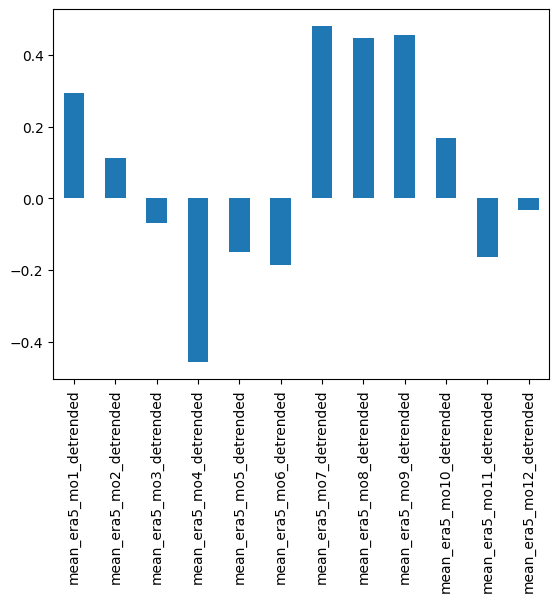

In [432]:
df_era5_monthwise.merge(
    df_emdat_yearly.rename(columns={"Start Year": "valid_year"})
).corr()["Total Affected"][
    [x for x in df_era5_monthwise if "detrended" in x]
].plot(
    kind="bar"
)

<Axes: >

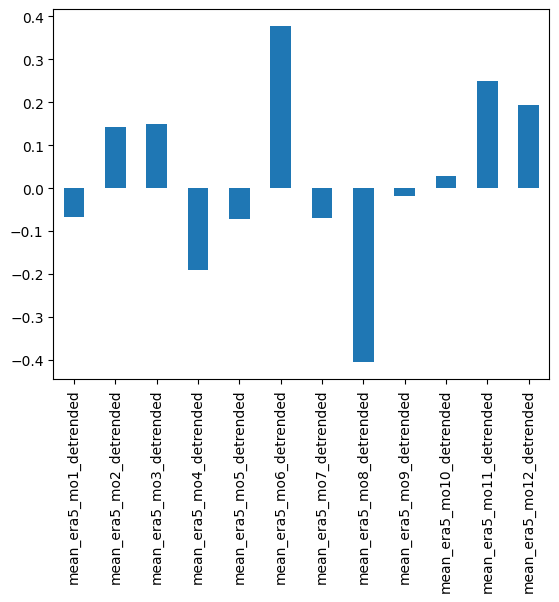

In [433]:
df_era5_monthwise.set_index("valid_year").shift().reset_index().merge(
    df_emdat_yearly.rename(columns={"Start Year": "valid_year"})
).corr()["Total Affected"][
    [x for x in df_era5_monthwise if "detrended" in x]
].plot(
    kind="bar"
)

## Combine

In [434]:
df_compare_full = (
    df_exp_yearly.merge(
        df_era5_yearly.rename(
            columns={
                "mean": "mean_era5",
                "mean_detrended": "mean_era5_detrended",
            }
        ),
        how="outer",
    )
    .merge(
        df_seas5_yearly,
        how="outer",
    )
    .rename(
        columns={
            "mean": "mean_seas5",
            "mean_detrended": "mean_seas5_detrended",
        }
    )
    .merge(
        df_emdat_yearly.rename(
            columns={
                "Start Year": "valid_date",
                "Total Affected": "total_affected",
            }
        ),
        how="outer",
    )
).rename(columns={"valid_date": "year"})
df_compare_full["cerf"] = df_compare_full["year"].isin(CERF_YEARS)
df_compare = df_compare_full[
    (df_compare_full["year"] < 2025) & (df_compare_full["year"] >= 2000)
].copy()
df_compare

,year,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,max_prev_exp,mean_prev_exp,mean_roll3_exp,max_diff_mean_roll3_exp,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended,total_affected,cerf
19,2000,36362.508197,97660.0,7472.0,90188.0,28890.508197,126544.0,42893.224658,46270.839388,2.110617,5.684529,5.587437,6.370819,6.410344,0.0,False
20,2001,43013.652055,129377.0,2423.0,126954.0,40590.652055,97660.0,36362.508197,40756.461636,3.174392,5.969749,5.911494,6.107337,6.131052,0.0,False
21,2002,21579.810959,44173.0,3374.0,40799.0,18205.810959,129377.0,43013.652055,33651.990403,1.312642,4.051516,4.032097,5.713399,5.721304,0.0,False
22,2003,42480.830137,102194.0,6037.0,96157.0,36443.830137,44173.0,21579.810959,35691.431050,2.863264,5.655184,5.674603,6.616325,6.608420,0.0,False
23,2004,29861.836066,66140.0,8338.0,57802.0,21523.836066,102194.0,42480.830137,31307.492387,2.112593,4.679939,4.738194,6.350943,6.327228,0.0,False
24,2005,41970.375342,81974.0,8870.0,73104.0,33100.375342,66140.0,29861.836066,38104.347182,2.151303,5.119211,5.216304,6.228102,6.188577,0.0,False
25,2006,47637.558904,118770.0,10580.0,108190.0,37057.558904,81974.0,41970.375342,39823.256771,2.982428,5.186454,5.322385,6.085460,6.030124,0.0,False
26,2007,60032.915068,156370.0,3439.0,152931.0,56593.915068,118770.0,47637.558904,49880.283105,3.134906,5.577635,5.752402,6.897371,6.826225,0.0,False
27,2008,57716.191257,153533.0,5749.0,147784.0,51967.191257,156370.0,60032.915068,55128.888410,2.784983,5.385251,5.598855,6.254890,6.167934,92791.0,False
28,2009,33345.947945,86897.0,10816.0,76081.0,22529.947945,153533.0,57716.191257,50365.018090,1.725344,4.490620,4.743061,6.279039,6.176273,0.0,False


In [435]:
df_compare_full

,year,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,max_prev_exp,mean_prev_exp,mean_roll3_exp,max_diff_mean_roll3_exp,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended,total_affected,cerf
0,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.370742,5.535743,6.368746,6.708666,NaN,False
1,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.253522,4.457360,5.503742,5.827851,NaN,False
2,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.121003,5.363678,5.300693,5.608992,NaN,False
3,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.780768,5.062280,5.864295,6.156784,NaN,False
4,1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.582485,5.902835,6.494820,6.771499,NaN,False
5,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.688345,5.047531,5.948166,6.209034,NaN,False
6,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.064137,4.462160,5.368880,5.613938,NaN,False
7,1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.550306,5.987167,6.449613,6.678861,NaN,False
8,1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.619099,5.094798,6.186039,6.399476,NaN,False
9,1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.567138,5.081673,6.164523,6.362151,NaN,False


## Analysis

### Correlations

In [436]:
df_compare.set_index("year").corr()

,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,max_prev_exp,mean_prev_exp,mean_roll3_exp,max_diff_mean_roll3_exp,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended,total_affected,cerf
mean_exp,1.000000,0.959560,0.953307,0.884003,0.961809,0.882305,0.891671,0.936750,-0.051598,-0.135118,0.106874,0.174408,0.011294,0.597188,0.607755
max_exp,0.959560,1.000000,0.845294,0.978483,0.985869,0.776937,0.757924,0.825612,0.202780,-0.037112,0.224648,0.250017,0.079781,0.641184,0.673251
min_exp,0.953307,0.845294,1.000000,0.716867,0.834234,0.943832,0.972415,0.977929,-0.256705,-0.273407,-0.054087,0.018281,-0.138544,0.480670,0.463720
max_diff_exp,0.884003,0.978483,0.716867,1.000000,0.964316,0.649357,0.613509,0.699706,0.363737,0.057151,0.314030,0.319188,0.157607,0.651067,0.699456
mean_diff_exp,0.961809,0.985869,0.834234,0.964316,1.000000,0.755504,0.746698,0.824008,0.138457,0.001101,0.244157,0.301872,0.146191,0.654715,0.689369
max_prev_exp,0.882305,0.776937,0.943832,0.649357,0.755504,1.000000,0.958229,0.916649,-0.297768,-0.430712,-0.228600,-0.147805,-0.302968,0.348922,0.338060
mean_prev_exp,0.891671,0.757924,0.972415,0.613509,0.746698,0.958229,1.000000,0.978387,-0.349148,-0.326535,-0.129760,-0.064682,-0.210270,0.387043,0.356947
mean_roll3_exp,0.936750,0.825612,0.977929,0.699706,0.824008,0.916649,0.978387,1.000000,-0.274989,-0.212516,0.006563,0.067928,-0.085164,0.505655,0.468451
max_diff_mean_roll3_exp,-0.051598,0.202780,-0.256705,0.363737,0.138457,-0.297768,-0.349148,-0.274989,1.000000,0.364887,0.470982,0.235159,0.187182,0.259965,0.266642
mean_era5,-0.135118,-0.037112,-0.273407,0.057151,0.001101,-0.430712,-0.326535,-0.212516,0.364887,1.000000,0.931185,0.603920,0.705839,0.250979,0.171376


In [437]:
df_compare_full.set_index("year").corr()[
    [x for x in df_compare_full.columns if "5" in x]
]

,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended
mean_exp,-0.150719,0.079771,0.280168,0.100049
max_exp,-0.052709,0.198863,0.304668,0.125961
min_exp,-0.303111,-0.094148,0.217135,0.037979
max_diff_exp,0.049230,0.296368,0.301625,0.150680
mean_diff_exp,0.001277,0.231818,0.303794,0.154914
max_prev_exp,-0.408485,-0.222744,0.009309,-0.159336
mean_prev_exp,-0.312942,-0.128395,0.120789,-0.040343
mean_roll3_exp,-0.212516,0.006563,0.234916,0.072292
max_diff_mean_roll3_exp,0.364887,0.470982,0.108668,0.091216
mean_era5,1.000000,0.805543,0.270034,0.534400


In [438]:
df_compare.set_index("year").corr()[
    [x for x in df_compare_full.columns if "5" in x]
]

,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended
mean_exp,-0.135118,0.106874,0.174408,0.011294
max_exp,-0.037112,0.224648,0.250017,0.079781
min_exp,-0.273407,-0.054087,0.018281,-0.138544
max_diff_exp,0.057151,0.314030,0.319188,0.157607
mean_diff_exp,0.001101,0.244157,0.301872,0.146191
max_prev_exp,-0.430712,-0.228600,-0.147805,-0.302968
mean_prev_exp,-0.326535,-0.129760,-0.064682,-0.210270
mean_roll3_exp,-0.212516,0.006563,0.067928,-0.085164
max_diff_mean_roll3_exp,0.364887,0.470982,0.235159,0.187182
mean_era5,1.000000,0.931185,0.603920,0.705839


Text(0, 0.5, 'TPR/PPV/F1')

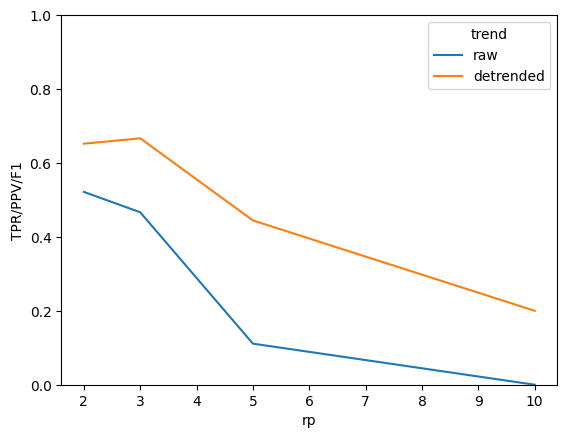

In [513]:
# quick F1 comparison between raw and detrended
dicts = []
df_compare_metrics = df_compare_full.copy()

for rp in [2, 3, 5, 10]:
    for trend in ["", "_detrended"]:
        for col in [f"mean_seas5{trend}", f"mean_era5{trend}"]:
            df_compare_metrics[f"{col}_bool"] = df_compare_metrics[
                col
            ] >= df_compare_metrics[col].quantile(1 - 1 / rp)
        p = df_compare_metrics[f"mean_seas5{trend}_bool"].sum()
        pp = df_compare_metrics[f"mean_era5{trend}_bool"].sum()
        tp = (
            df_compare_metrics[
                [f"mean_era5{trend}_bool", f"mean_seas5{trend}_bool"]
            ]
            .all(axis=1)
            .sum()
        )
        tpr = tp / p
        dicts.append(
            {
                "rp": rp,
                "tpr": tpr,
                "trend": "raw" if trend == "" else "detrended",
            }
        )

df_plot_metrics = pd.DataFrame(dicts)
ax = df_plot_metrics.pivot(index="rp", columns="trend", values="tpr")[
    ["raw", "detrended"]
].plot()
ax.set_ylim(0, 1)
ax.set_ylabel("TPR/PPV/F1")

<Axes: >

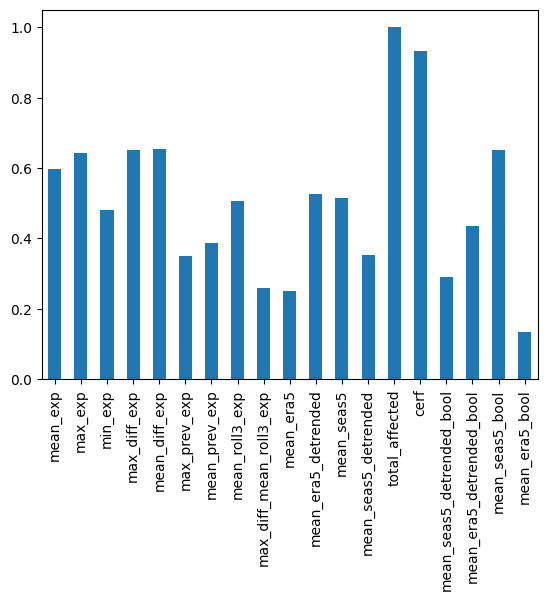

In [514]:
df_compare.set_index("year").corr()["total_affected"].plot(kind="bar")

<Axes: >

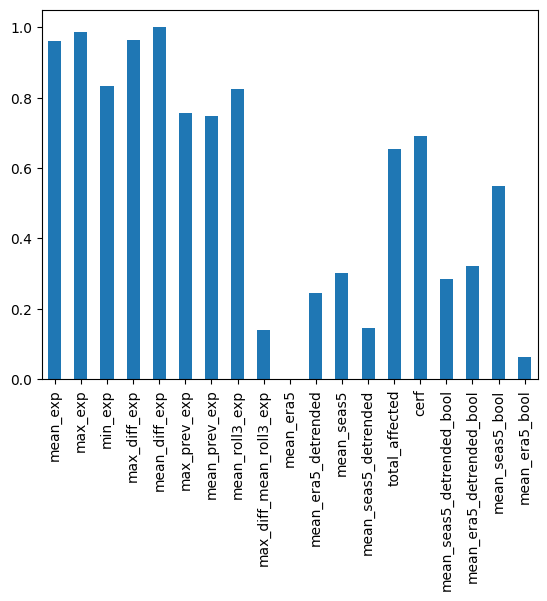

In [515]:
df_compare.set_index("year").corr()["mean_diff_exp"].plot(kind="bar")

<Axes: >

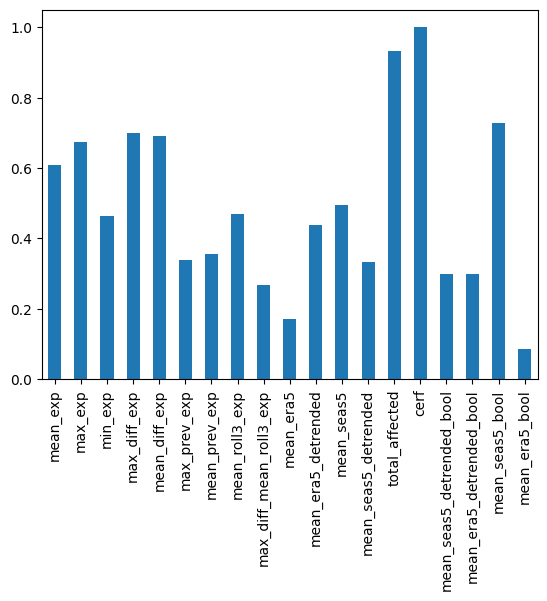

In [516]:
df_compare.set_index("year").corr()["cerf"].plot(kind="bar")

### Plotting

In [517]:
def plot_comparison(df, xcol, ycol, sizecol=None, labels=None, rotation=0):
    df = df.copy()
    fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

    # Replace NaN sizes with a small value
    if sizecol is None:
        sizes = np.full(len(df), 0)
    else:
        sizes = df[sizecol].fillna(0) / df[sizecol].max() * 1000

    # Set colors based on cerf
    df["color"] = df["cerf"].map({True: "crimson", False: "royalblue"})

    scatter = ax.scatter(
        df[xcol], df[ycol], s=sizes, c=df["color"], alpha=0.5, edgecolor="none"
    )

    # Annotate year on each point
    for year, row in df.set_index("year").iterrows():
        ax.annotate(
            str(year),
            (row[xcol], row[ycol]),
            fontsize=8,
            ha="center",
            va="center",
            color=row["color"],
            rotation=rotation,
        )

    if labels is None:
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.set_title("")
    else:
        ax.set_xlabel(labels["x"])
        ax.set_ylabel(labels["y"])
        ax.set_title(labels["title"])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return fig, ax

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: title={'center': 'Impact vs. exposure comparison'}, xlabel='Average adjusted flood exposure during year [Floodscan]', ylabel='Total people affected during year [EM-DAT]'>)

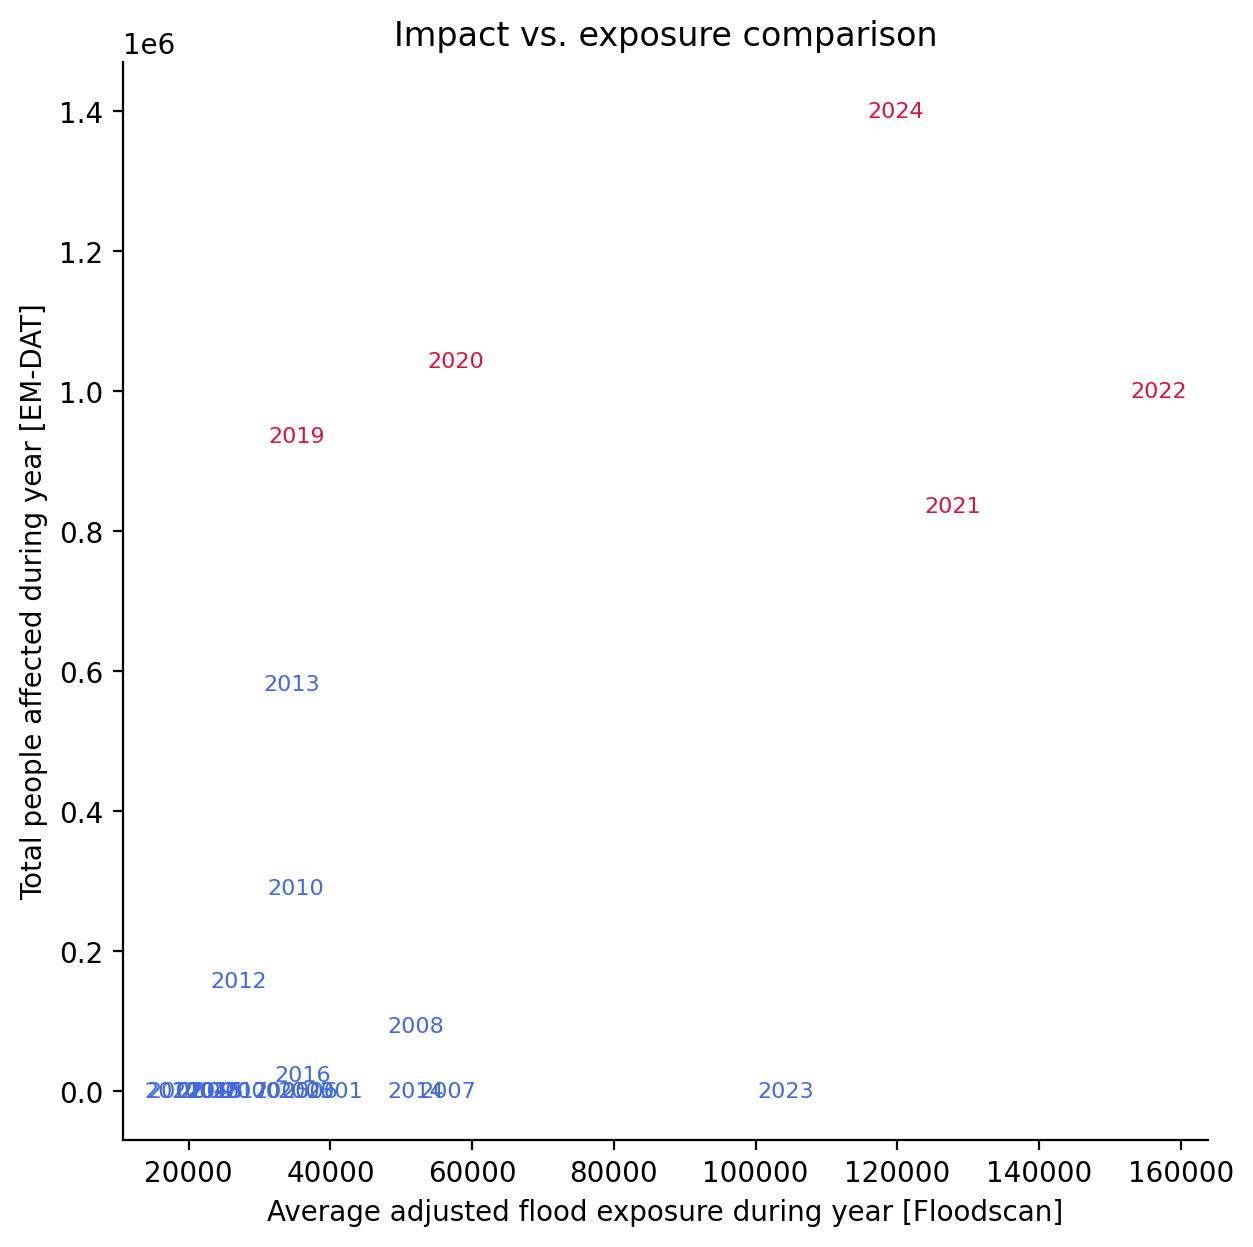

In [518]:
plot_comparison(
    df_compare,
    "mean_diff_exp",
    "total_affected",
    labels={
        "x": "Average adjusted flood exposure during year [Floodscan]",
        "y": "Total people affected during year [EM-DAT]",
        "title": "Impact vs. exposure comparison",
    },
)

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: title={'center': 'Impact vs. exposure comparison'}, xlabel='Average adjusted flood exposure during year [Floodscan]', ylabel='Total people affected during year [EM-DAT]'>)

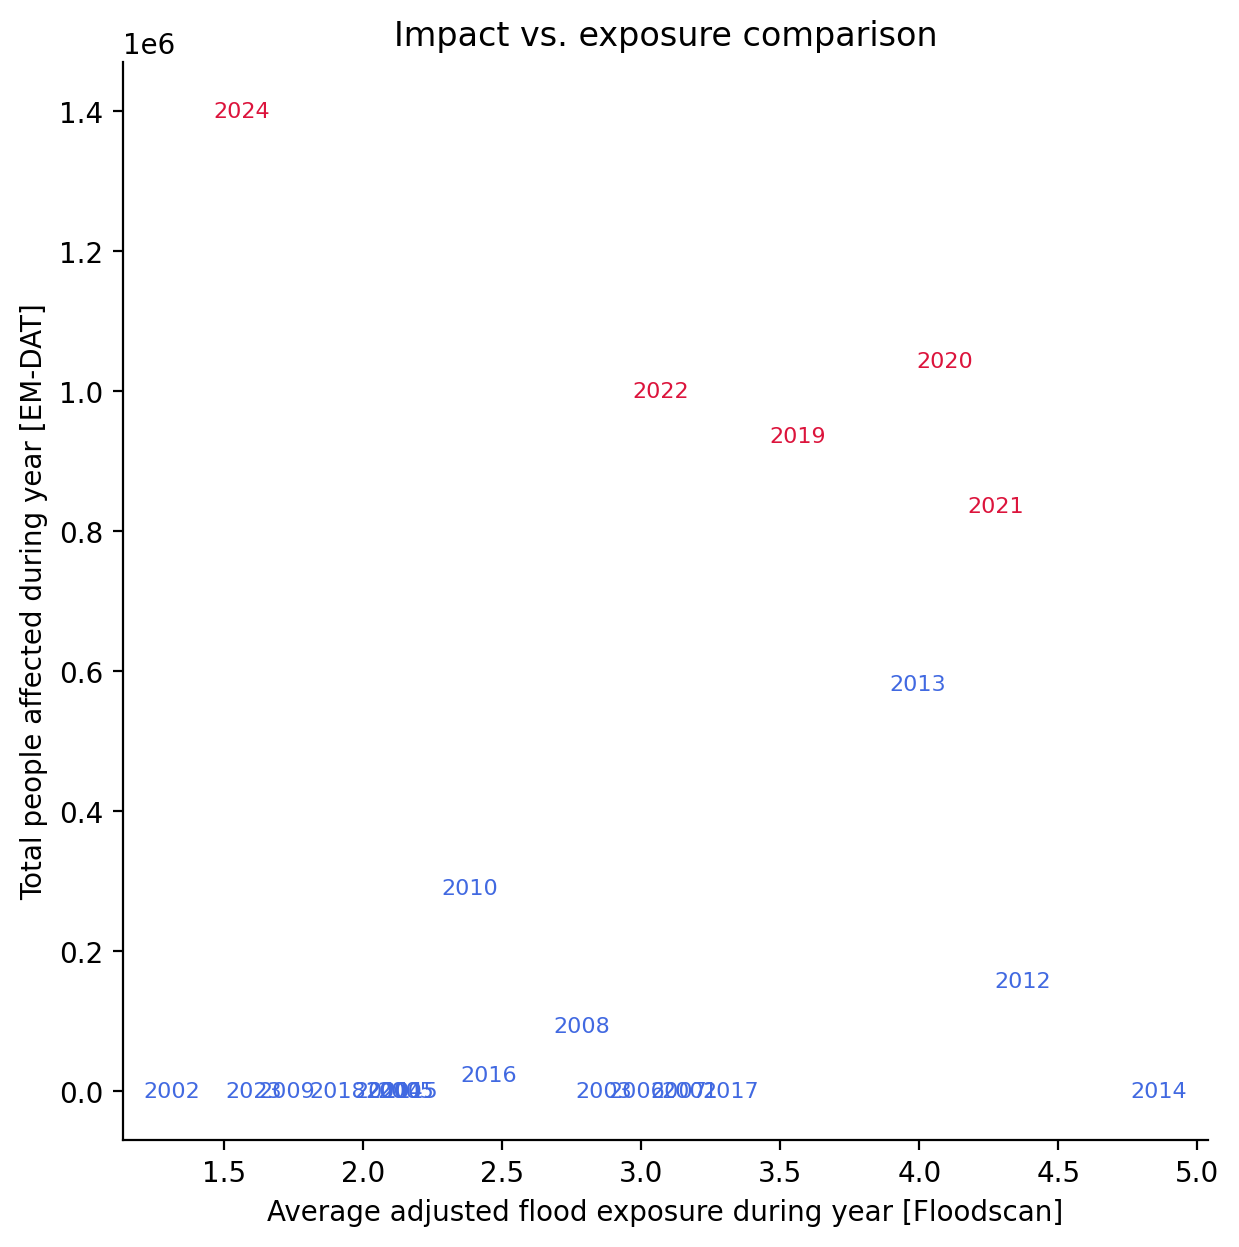

In [519]:
plot_comparison(
    df_compare,
    "max_diff_mean_roll3_exp",
    "total_affected",
    labels={
        "x": "Average adjusted flood exposure during year [Floodscan]",
        "y": "Total people affected during year [EM-DAT]",
        "title": "Impact vs. exposure comparison",
    },
)

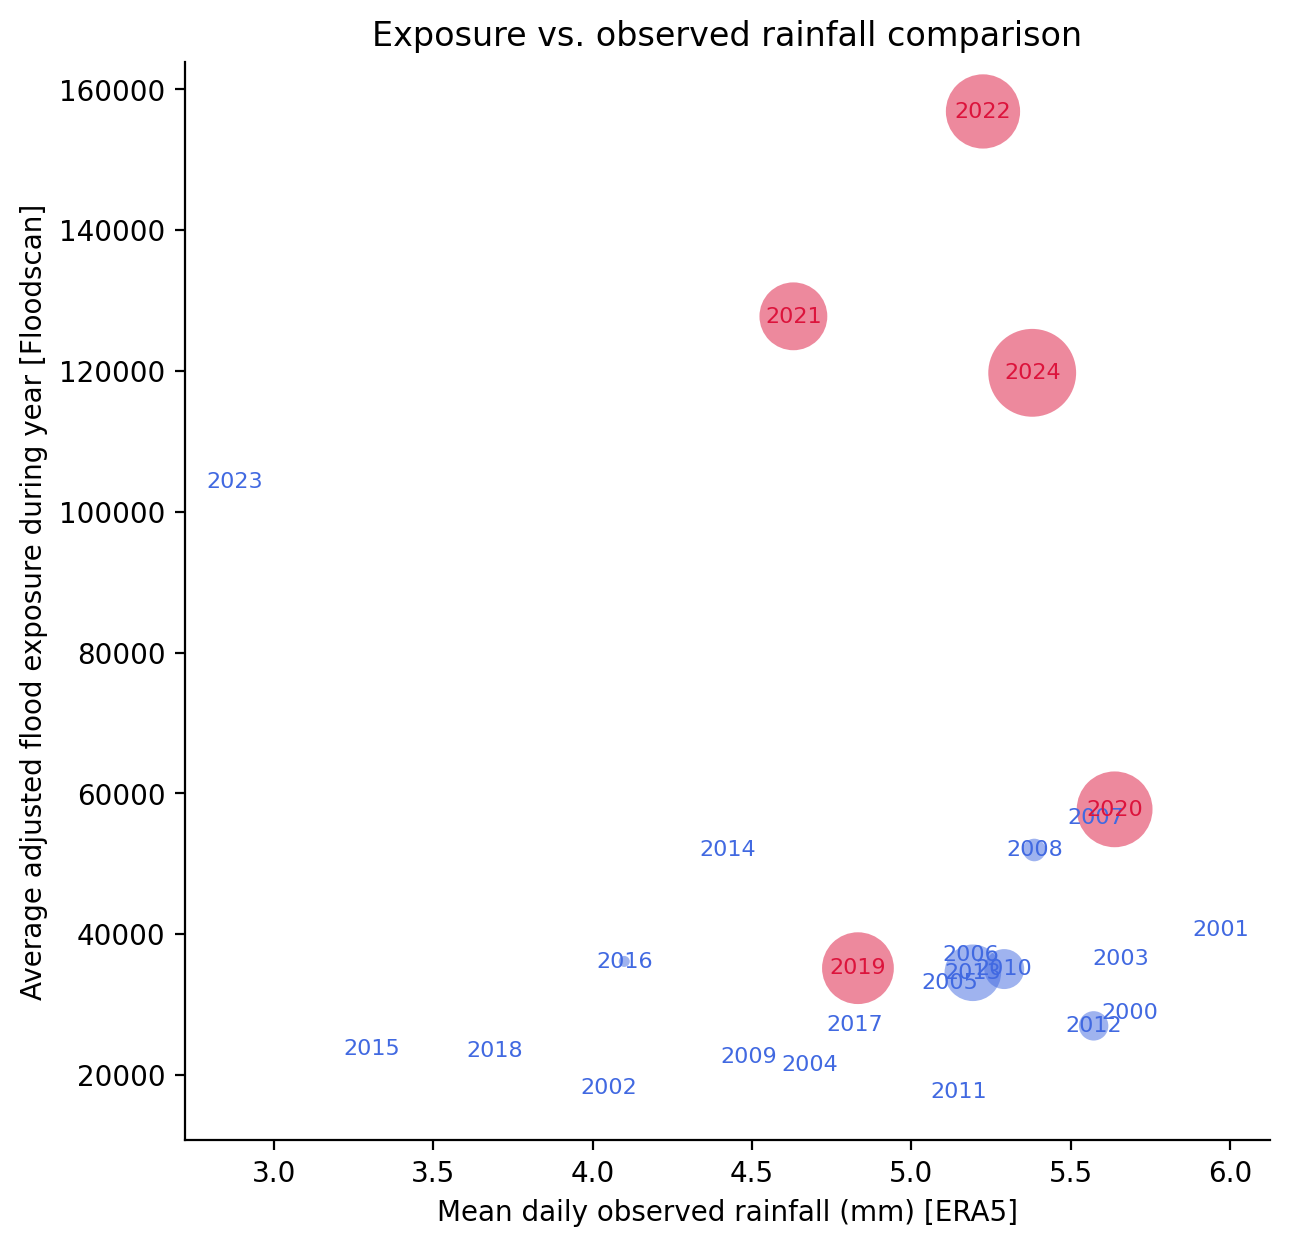

In [520]:
fig, ax = plot_comparison(
    df_compare,
    "mean_era5",
    "mean_diff_exp",
    sizecol="total_affected",
    labels={
        "x": "Mean daily observed rainfall (mm) [ERA5]",
        "y": "Average adjusted flood exposure during year [Floodscan]",
        "title": "Exposure vs. observed rainfall comparison",
    },
)

Text(7.196289266666667, 156878.63287671233, '2025 forecast')

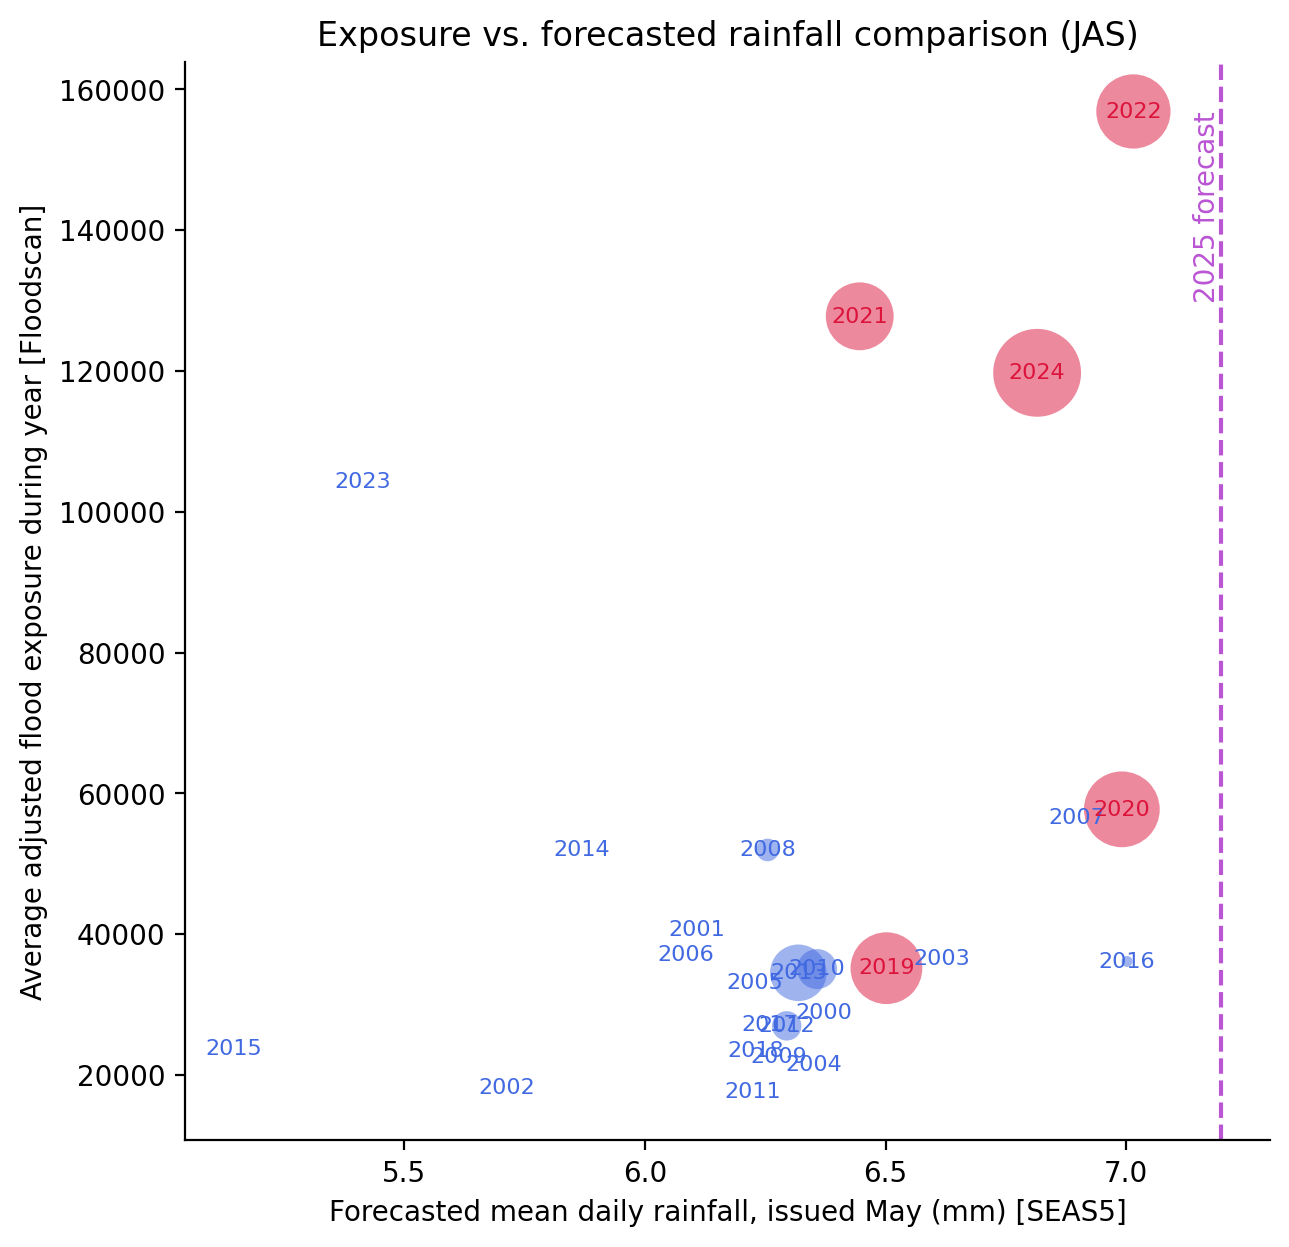

In [521]:
fig, ax = plot_comparison(
    df_compare,
    "mean_seas5",
    "mean_diff_exp",
    sizecol="total_affected",
    labels={
        "x": f"Forecasted mean daily rainfall, issued {issued_mo_str} (mm) [SEAS5]",
        "y": "Average adjusted flood exposure during year [Floodscan]",
        "title": f"Exposure vs. forecasted rainfall comparison ({valid_mo_str})",
    },
)

current_val = df_seas5_yearly.set_index("valid_date").loc[2025]["mean"]

ax.axvline(
    current_val,
    color="mediumorchid",
    linestyle="--",
)
ax.annotate(
    "2025 forecast",
    (current_val, df_compare["mean_diff_exp"].max()),
    rotation=90,
    va="top",
    ha="right",
    color="mediumorchid",
)

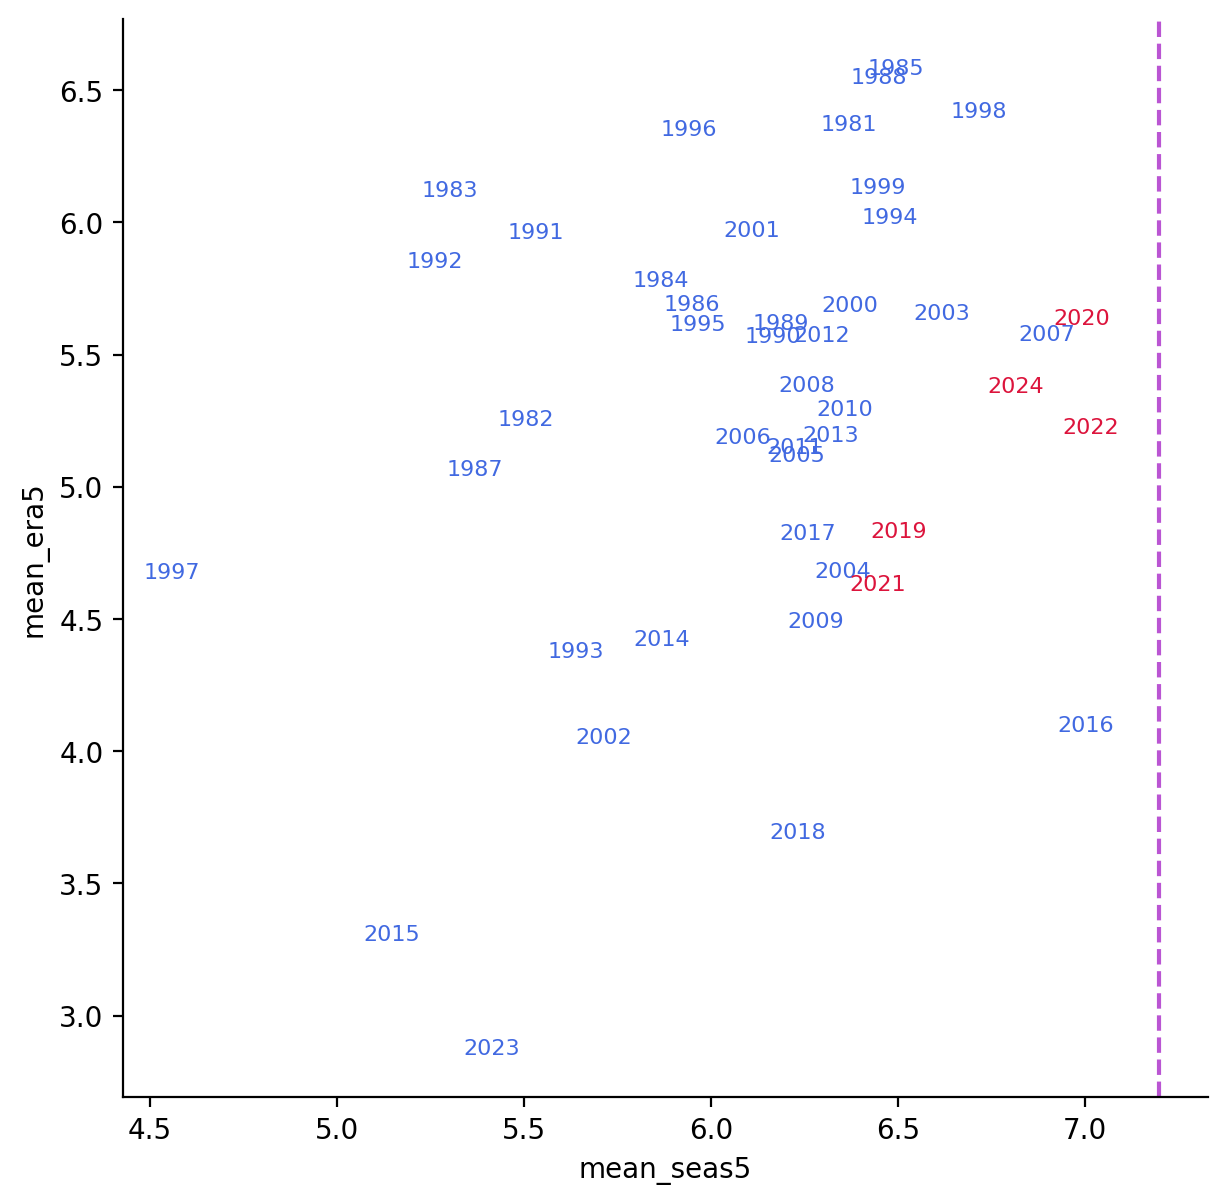

In [522]:
fig, ax = plot_comparison(
    df_compare_full,
    "mean_seas5",
    "mean_era5",
)

current_pred = df_compare_full.set_index("year").loc[2025, "mean_seas5"]
ax.axvline(
    current_pred,
    color="mediumorchid",
    linestyle="--",
)

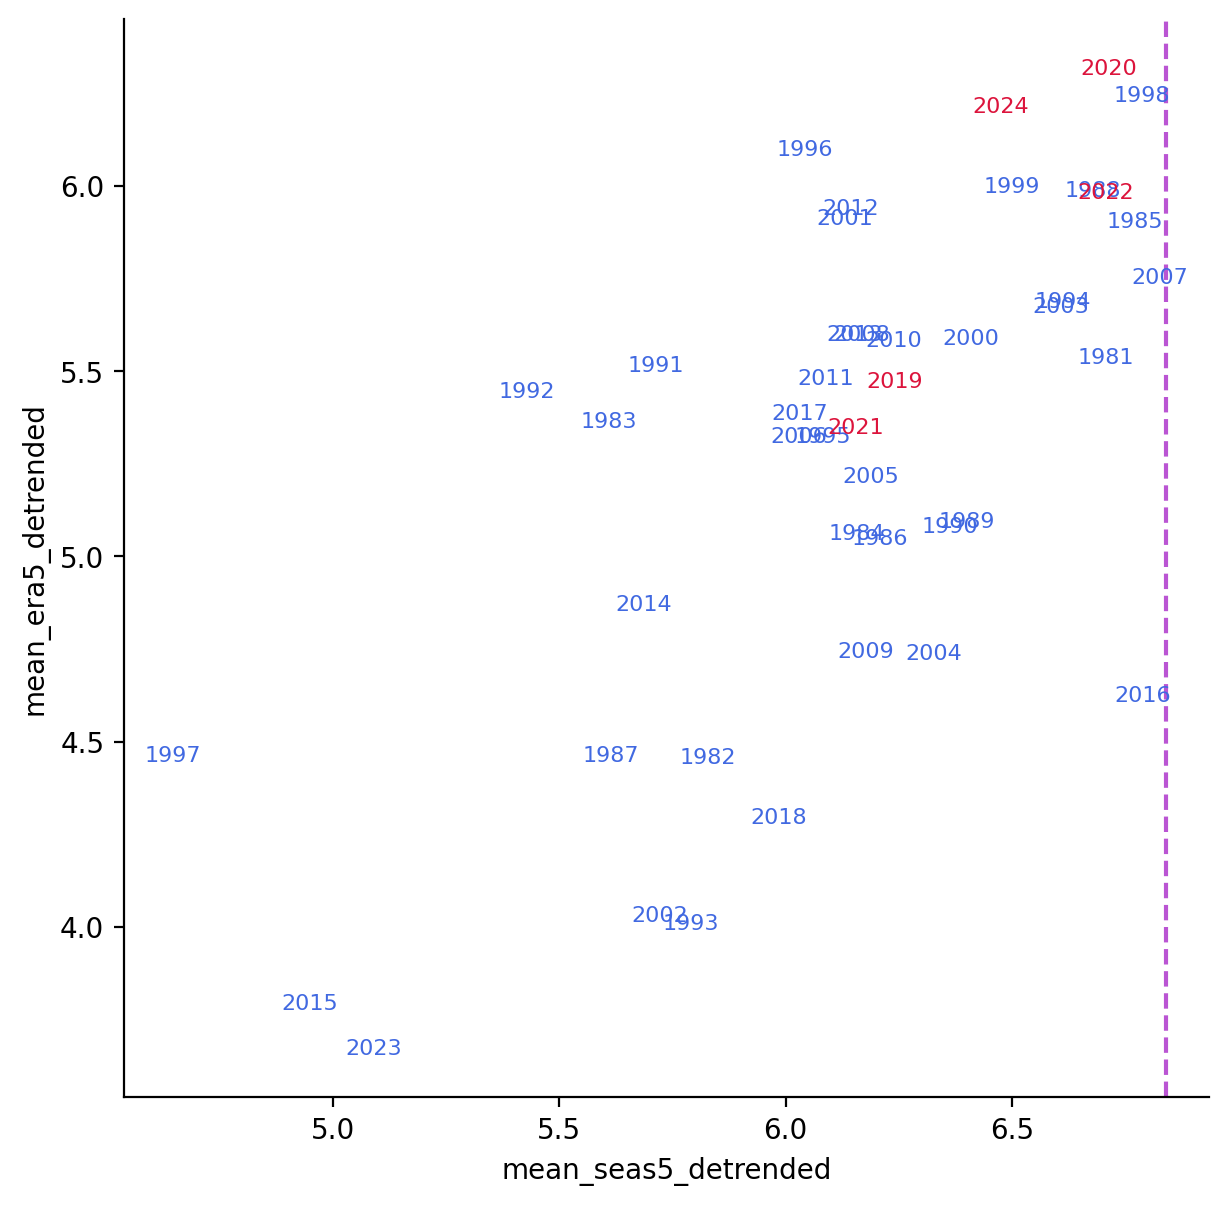

In [523]:
fig, ax = plot_comparison(
    df_compare_full,
    "mean_seas5_detrended",
    "mean_era5_detrended",
)

current_pred = df_compare_full.set_index("year").loc[
    2025, "mean_seas5_detrended"
]
ax.axvline(
    current_pred,
    color="mediumorchid",
    linestyle="--",
)

Text(0.5, 0, 'Forecasted mean daily rainfall, detrended, issued May (mm) [SEAS5]')

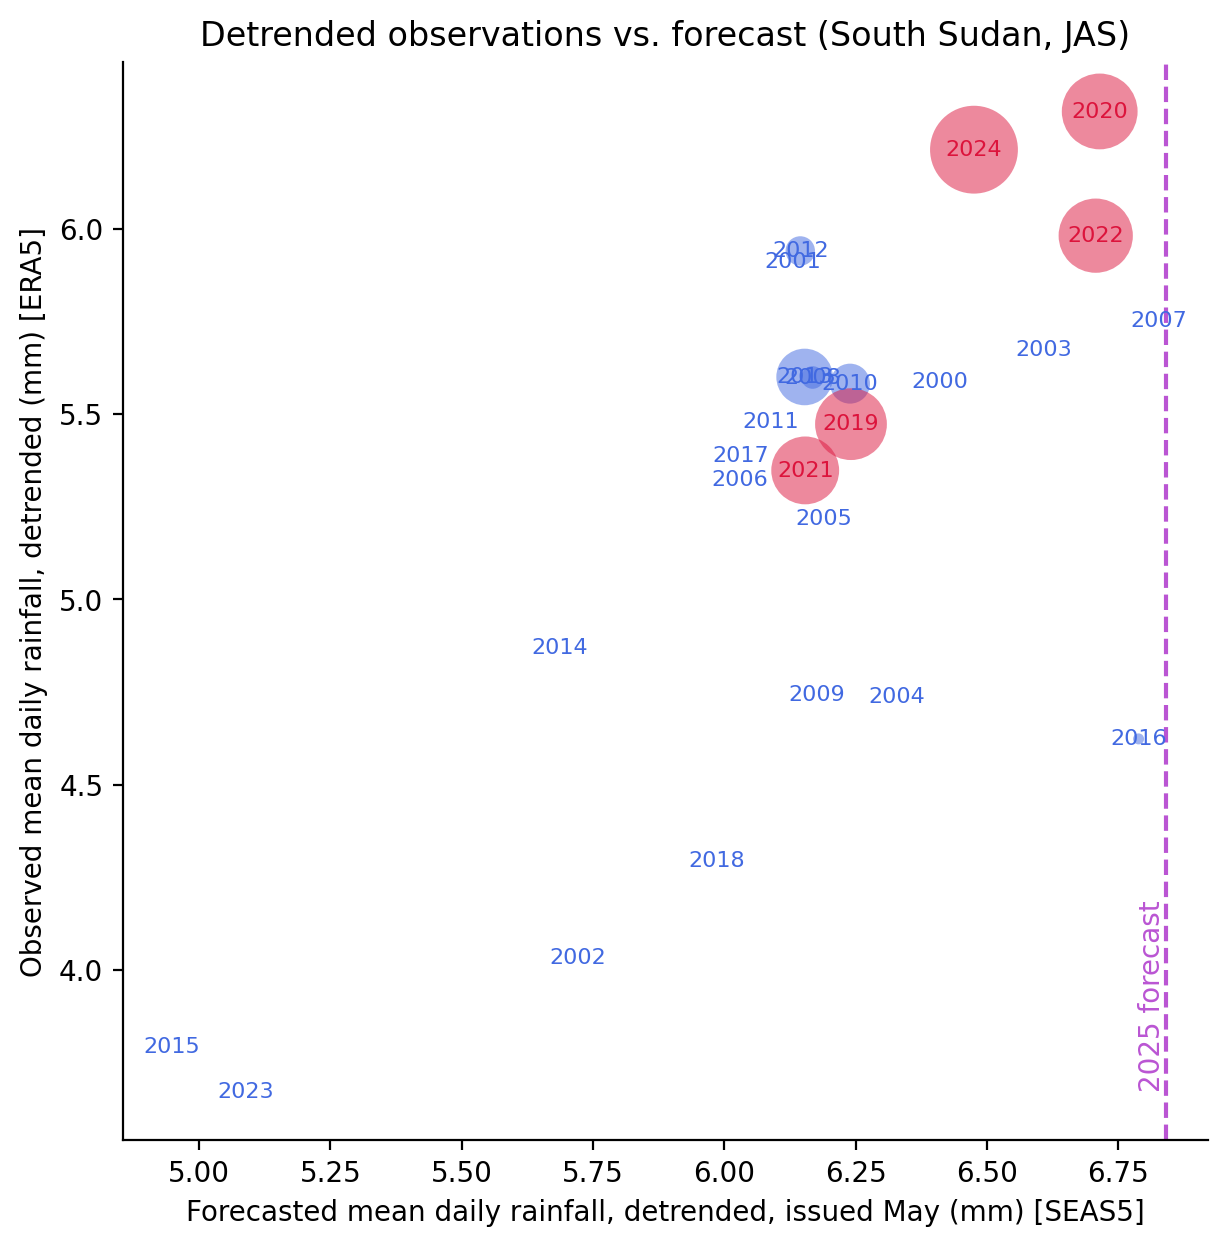

In [524]:
fig, ax = plot_comparison(
    df_compare,
    "mean_seas5_detrended",
    "mean_era5_detrended",
    sizecol="total_affected",
)

current_pred = df_compare_full.set_index("year").loc[
    2025, "mean_seas5_detrended"
]
ax.axvline(
    current_pred,
    color="mediumorchid",
    linestyle="--",
)
ax.annotate(
    "2025 forecast",
    (current_pred, df_compare["mean_era5_detrended"].min()),
    rotation=90,
    va="bottom",
    ha="right",
    color="mediumorchid",
)

ax.set_title(
    f"Detrended observations vs. forecast ({adm_name}, {valid_mo_str})"
)
ax.set_ylabel(f"Observed mean daily rainfall, detrended (mm) [ERA5]")
ax.set_xlabel(
    f"Forecasted mean daily rainfall, detrended, issued {issued_mo_str} (mm) [SEAS5]"
)

## Modeling

In [525]:
df_modeling = df_compare_full.copy()
# df_modeling = df_modeling[
#     (df_modeling["year"] >= 2006) & (df_modeling["year"] < 2025)
# ]
df_modeling["year_dummy"] = (df_modeling["year"] >= 2019).astype(int)

In [526]:
df_modeling.loc[df_modeling["year"] == 2025, "mean_diff_exp"] = np.nan

In [530]:
# Select inputs and output
input_cols = ["year_dummy", "mean_seas5"]
# input_cols = ["min_exp", "mean_seas5"]
output_col = "total_affected"
X = df_modeling[input_cols]
y = df_modeling[output_col]

# Drop rows with missing values
df_clean = pd.concat([X, y], axis=1).dropna()
X = df_clean[input_cols]
y = df_clean[output_col]

# Add constant for intercept
X = sm.add_constant(X)

# Fit linear regression model
model = sm.OLS(y, X).fit()

# Show summary
print(model.summary())

df_modeling["reg_pred"] = model.predict(
    sm.add_constant(df_modeling[input_cols])
)

                            OLS Regression Results                            
Dep. Variable:         total_affected   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     34.72
Date:                Tue, 06 May 2025   Prob (F-statistic):           1.56e-07
Time:                        12:09:42   Log-Likelihood:                -341.50
No. Observations:                  25   AIC:                             689.0
Df Residuals:                      22   BIC:                             692.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.781e+06   6.41e+05     -2.776      0.0

<Axes: >

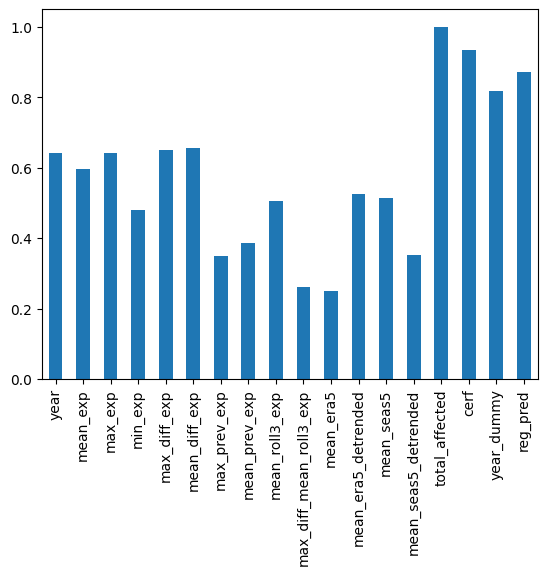

In [531]:
df_modeling.corr()["total_affected"].plot(kind="bar")

Text(0.5, 1.04, 'Variables: Apr SEAS5 forecast, min. exposure during year')

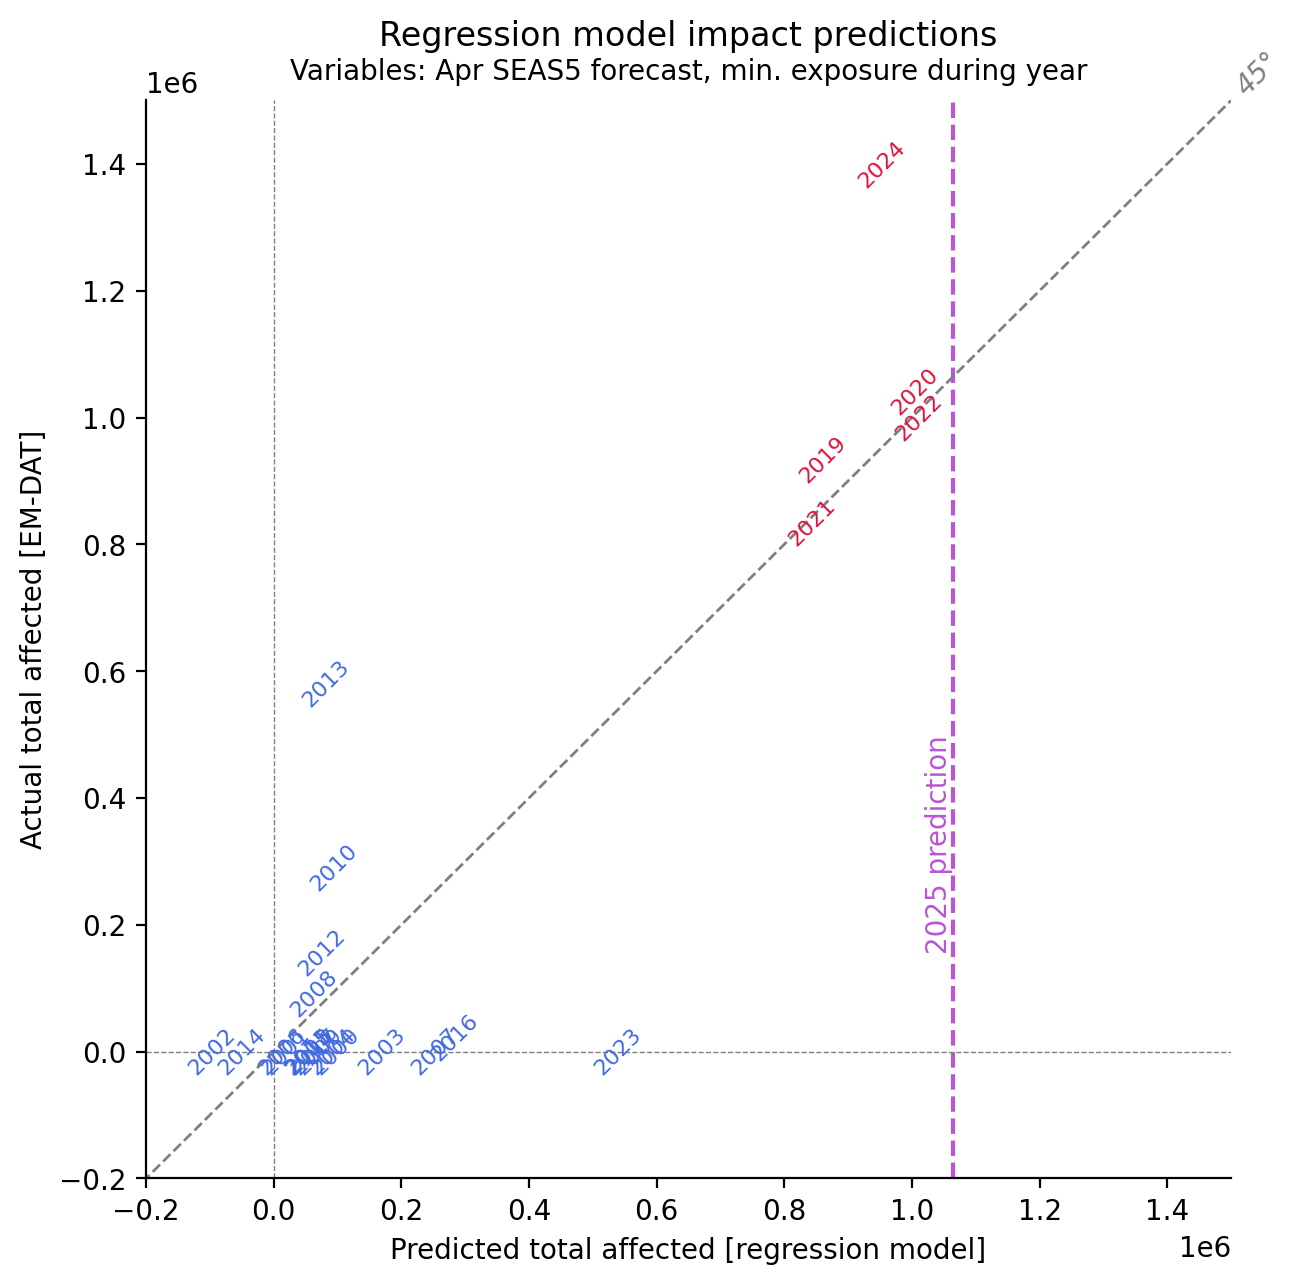

In [532]:
ycol = output_col
xcol = "reg_pred"
fig, ax = plot_comparison(
    df_modeling,
    xcol,
    ycol,
    rotation=45,
)
current_pred = df_modeling.set_index("year").loc[2025, xcol]
ax.axvline(
    current_pred,
    color="mediumorchid",
    linestyle="--",
)
ax.annotate(
    "2025 prediction",
    (current_pred, 0.5e6),
    rotation=90,
    va="top",
    ha="right",
    color="mediumorchid",
)
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.plot([-2e6, 2e6], [-2e6, 2e6], color="grey", linewidth=1, linestyle="--")
ax.annotate(
    "45°",
    (1.5e6, 1.5e6),
    color="grey",
    rotation=45,
    fontstyle="italic",
    va="bottom",
    ha="left",
)
ax.set_ylim([-0.2e6, 1.5e6])
ax.set_xlim([-0.2e6, 1.5e6])

ax.set_ylabel("Actual total affected [EM-DAT]")
ax.set_xlabel("Predicted total affected [regression model]")

ax.set_title("Regression model impact predictions\n")
ax.text(
    0.5,
    1.04,
    # "Variables: Apr SEAS5 forecast, ≥2019 dummy",
    "Variables: Apr SEAS5 forecast, min. exposure during year",
    transform=ax.transAxes,
    ha="center",
    va="top",
)